# Recursos léxicos (lexicons)

*   Son colecciones de palabras o frases que tienen asociadas etiquetas o meta-informacion de algún tipo (POS tags, significados gramaticales, etc ...)

In [ ]:
import nltk
nltk.download('book')
from nltk.book import *
from nltk.corpus import stopwords

# STOPWORDS:

In [2]:
def stopwords_percentage(text):
  '''
  aqui usamos un recurso léxico (stopwords) para filtrar un corpus
  '''
  stopwd = stopwords.words('english')
  content = [w  for w in text if w.lower() not in stopwd]
  return len(content)/len(text)

stopwords_percentage(text1)

0.5862954769399469

# swadesh
## Lexicons enriquecidos (listas comparativas de palabras)

*   Construyendo diccionarios para traduccion de palabras en diferentes idiomas.

In [3]:
from nltk.corpus import swadesh
#idiomas disponibles
print(swadesh.fileids())

['be', 'bg', 'bs', 'ca', 'cs', 'cu', 'de', 'en', 'es', 'fr', 'hr', 'it', 'la', 'mk', 'nl', 'pl', 'pt', 'ro', 'ru', 'sk', 'sl', 'sr', 'sw', 'uk']


In [ ]:
traductor_es_en = swadesh.entries(['es','en'])
traductor_es_en

In [5]:

traductor = dict(traductor_es_en)
traductor['bueno']

'good'

# WordNet
## Referencias

* [WordNet Lecture](https://sp1718.github.io/wordnet_lecture.pdf)
* [What is WordNet?](https://wordnet.princeton.edu)
* [WordNet Interface NLTK](http://www.nltk.org/howto/wordnet.html)
* [LAS-WordNet](https://www.datos.gov.co/Ciencia-Tecnolog-a-e-Innovaci-n/LAS-WordNet-una-WordNet-para-el-espa-ol-obtenida-c/8z8d-85m7)


In [10]:
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [11]:
# synset: grupo de sinómimos de una palabra.
ss = wn.synsets('carro', lang='spa')
ss

[Synset('car.n.01'),
 Synset('carriage.n.04'),
 Synset('carrier.n.02'),
 Synset('cart.n.01'),
 Synset('chariot.n.02'),
 Synset('cartload.n.01')]

In [12]:
# explorando los synsets
for syn in ss:
  print(syn.name(), ': ', syn.definition())
  for name in syn.lemma_names():
    print(' * ', name)

car.n.01 :  a motor vehicle with four wheels; usually propelled by an internal combustion engine
 *  car
 *  auto
 *  automobile
 *  machine
 *  motorcar
carriage.n.04 :  a machine part that carries something else
 *  carriage
carrier.n.02 :  a self-propelled wheeled vehicle designed specifically to carry something
 *  carrier
cart.n.01 :  a heavy open wagon usually having two wheels and drawn by an animal
 *  cart
chariot.n.02 :  a two-wheeled horse-drawn battle vehicle; used in war and races in ancient Egypt and Greece and Rome
 *  chariot
cartload.n.01 :  the quantity that a cart holds
 *  cartload


In [13]:
# visualization references
# * http://www.randomhacks.net/2009/12/29/visualizing-wordnet-relationships-as-graphs/
# * http://dlacombejr.github.io/programming/2015/09/28/visualizing-cifar-10-categories-with-wordnet-and-networkx.html

import networkx as nx
import matplotlib.pyplot as plt

def closure_graph(synset, fn):
    seen = set()
    graph = nx.DiGraph()
    labels = {}

    def recurse(s):
        if not s in seen:
            seen.add(s)
            labels[s.name] = s.name().split('.')[0]
            graph.add_node(s.name)
            for s1 in fn(s):
                graph.add_node(s1.name)
                graph.add_edge(s.name, s1.name)
                recurse(s1)

    recurse(synset)
    return graph, labels

def draw_text_graph(G, labels):
    plt.figure(figsize=(18,12))
    pos = nx.planar_layout(G, scale=18)
    nx.draw_networkx_nodes(G, pos, node_color="red", linewidths=0, node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=20, labels=labels)
    nx.draw_networkx_edges(G, pos)
    plt.xticks([])
    plt.yticks([])

## **Hyponyms:** Conceptos que son más especificos que la palabra raiz de la cual derivan.

car.n.01


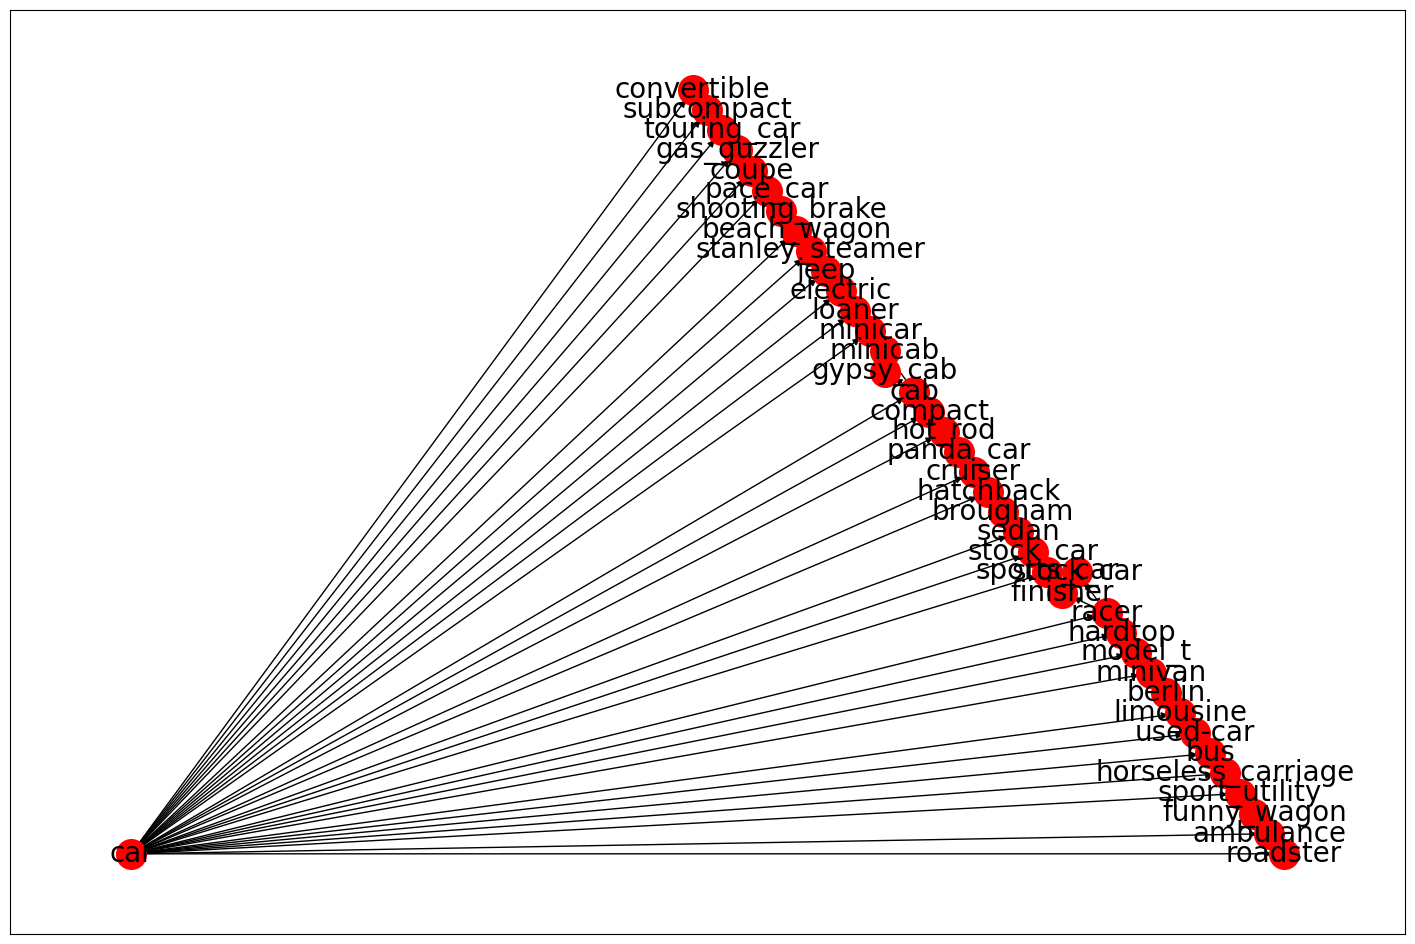

In [14]:
print(ss[0].name())
G, labels = closure_graph(ss[0], fn = lambda s: s.hyponyms())
draw_text_graph(G, labels)

## **Hypernyms**: conceptos que son mas generales !

car.n.01


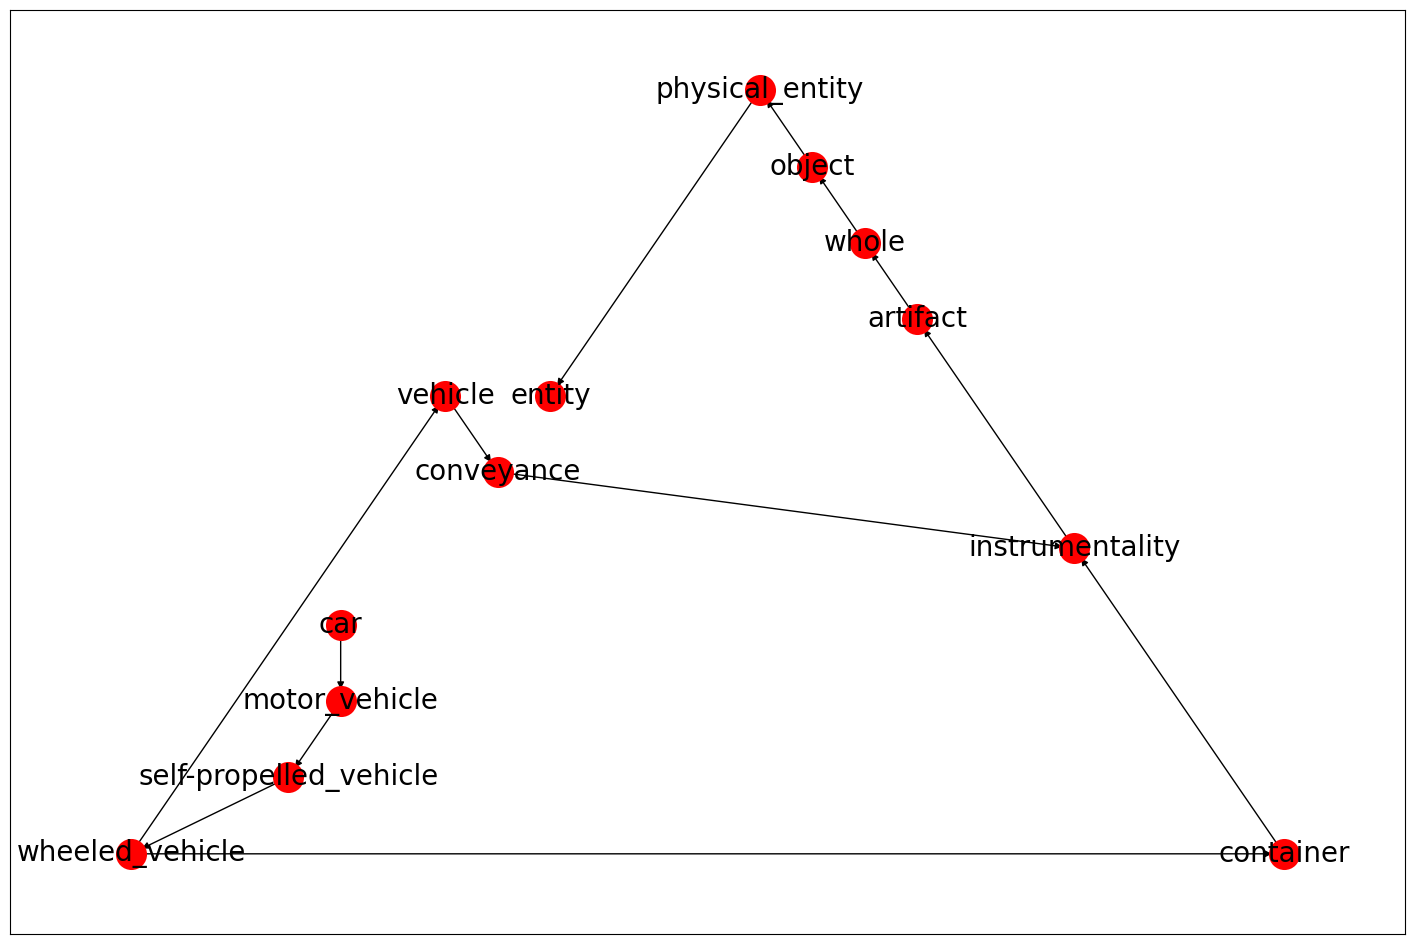

In [15]:
print(ss[0].name())
G, labels = closure_graph(ss[0], fn = lambda s: s.hypernyms())
draw_text_graph(G, labels)